# EDA on Retail Sales Data
**Task 1 — Data Analytics Track**

Dataset: Download the **Superstore Sales dataset** from Kaggle (search "superstore sales" or "retail sales dataset") and place the CSV in the same folder as this notebook. Update the filename in the cell below.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# CHANGE THIS to your actual downloaded file name
FILENAME = 'train.csv'
df = pd.read_csv(FILENAME, encoding='latin1')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## 1. Initial Inspection


In [2]:
print('Shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes)
print('\nNull values per column:')
print(df.isnull().sum())


Shape: (9800, 18)

Column dtypes:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

Null values per column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


**Observation:** *(write what you notice here — e.g. number of rows/columns, which columns have missing values, any obvious data type issues)*


## 2. Descriptive Statistics


In [3]:
num_cols = df.select_dtypes(include=np.number).columns
desc = df[num_cols].describe()
desc.loc['mode'] = df[num_cols].mode().iloc[0]
desc


,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000
mode,1.000000,10035.000000,12.960000


**Observation:** *(note which columns have high variance, unusual means vs medians, etc.)*


## 3. Time Series Analysis


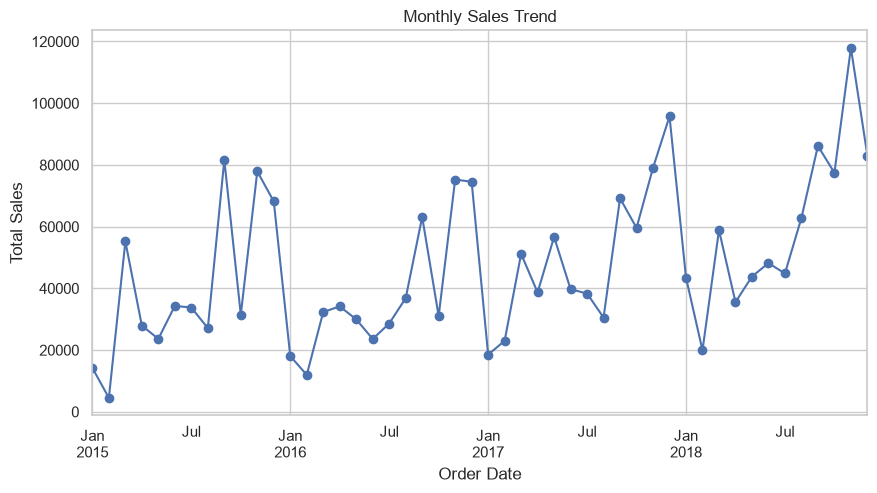

In [14]:
# Adjust 'Order Date' and 'Sales' to match your dataset's actual column names
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()
monthly_sales.plot(kind='line', marker='o', title='Monthly Sales Trend')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
quarterly_sales = df.set_index('Order Date').resample('Q')['Sales'].sum()
quarterly_sales.plot(kind='line', marker='o', color='darkorange', title='Quarterly Sales Trend')
plt.ylabel('Total Sales')
plt.show()


**Observation:** *(are there seasonal peaks? Growth or decline trend? Any anomalies?)*


## 4. Customer Demographics
*Note: if your dataset lacks Age/Gender (common in Superstore-style data), substitute Segment and Region — mention this substitution in your write-up.*


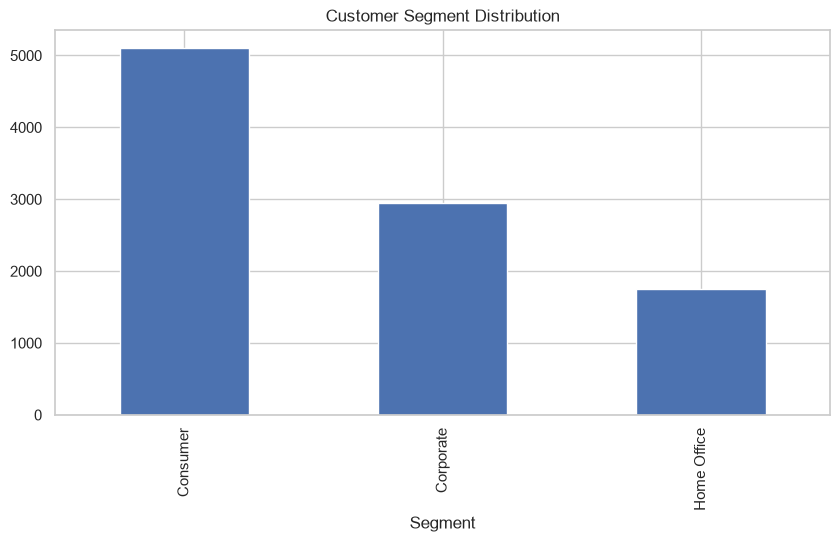

In [5]:
if 'Segment' in df.columns:
    df['Segment'].value_counts().plot(kind='bar', title='Customer Segment Distribution')
    plt.show()
else:
    print('No Segment column found — adjust to your dataset (e.g. Age, Gender).')


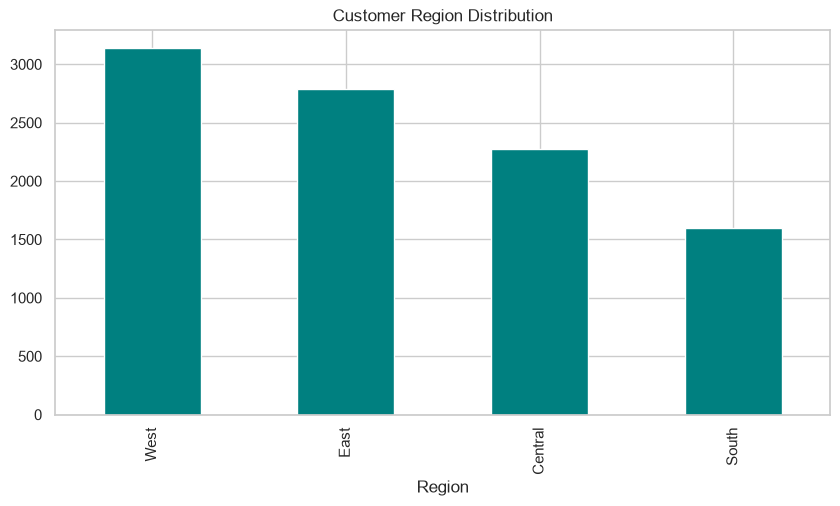

In [6]:
if 'Region' in df.columns:
    df['Region'].value_counts().plot(kind='bar', color='teal', title='Customer Region Distribution')
    plt.show()


**Observation:** *(which segment/region dominates? Any surprising imbalance?)*


## 5. Product Analysis


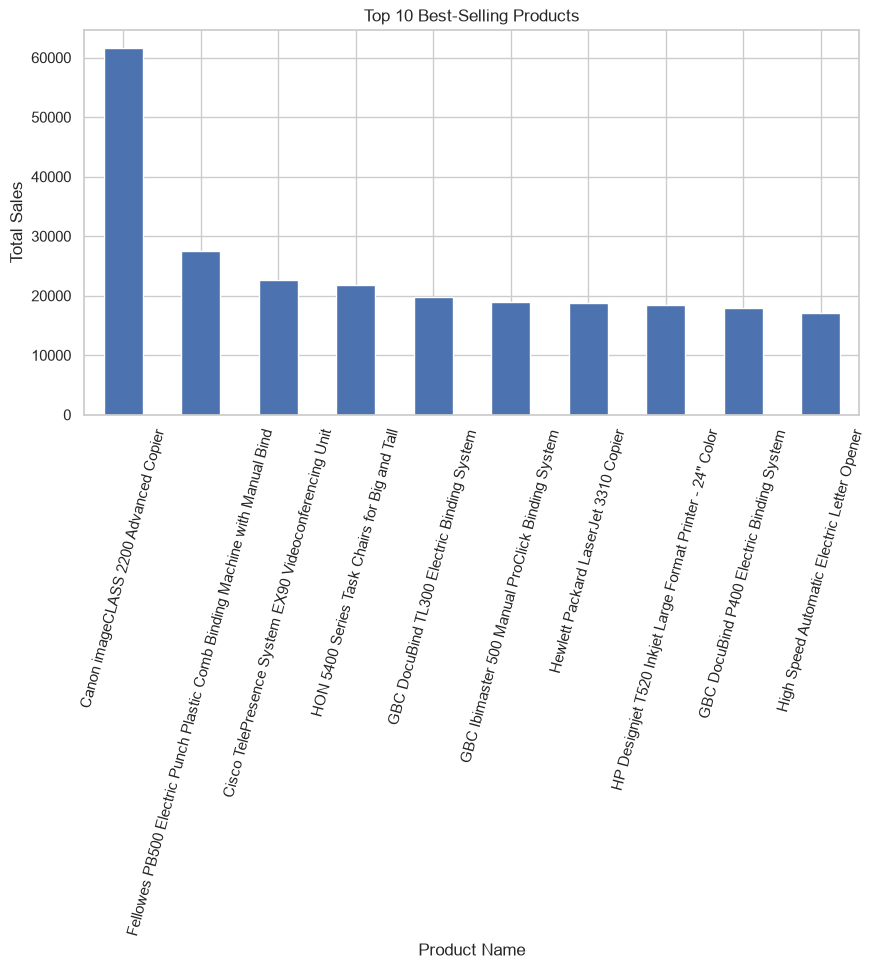

In [7]:
top10 = df.groupby('Product Name')['Sales'].sum().nlargest(10)
top10.plot(kind='bar', title='Top 10 Best-Selling Products')
plt.ylabel('Total Sales')
plt.xticks(rotation=75)
plt.show()


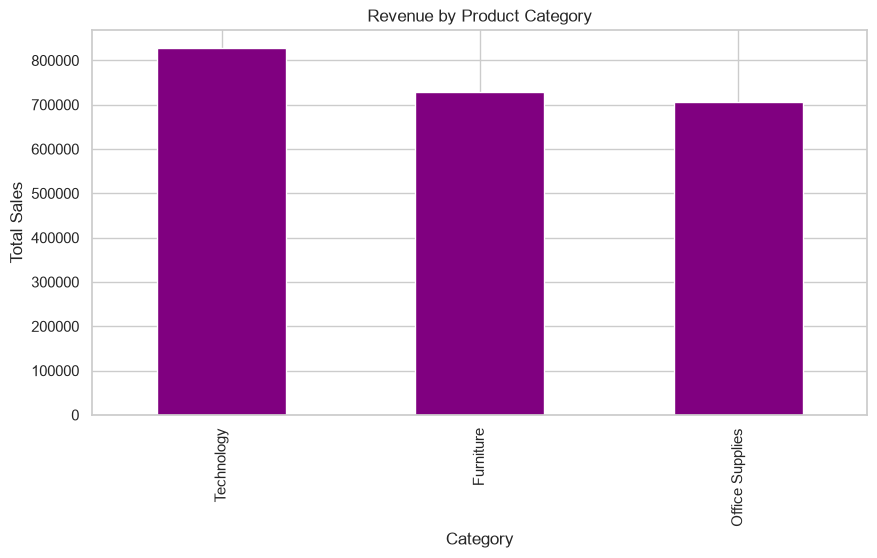

In [8]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
cat_sales.plot(kind='bar', color='purple', title='Revenue by Product Category')
plt.ylabel('Total Sales')
plt.show()


**Observation:** *(which products/categories drive most revenue? Is revenue concentrated or spread out?)*


## 6. Correlation Heatmap


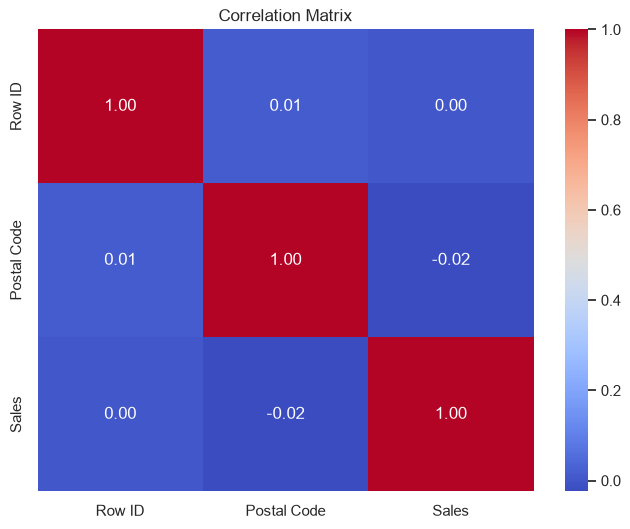

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


**Observation:** *(any strong positive/negative correlations? E.g. Discount vs Profit?)*


## 7. Additional Insight (Your Choice)
Example below: Discount vs Profit scatter — replace with your own idea if you prefer.


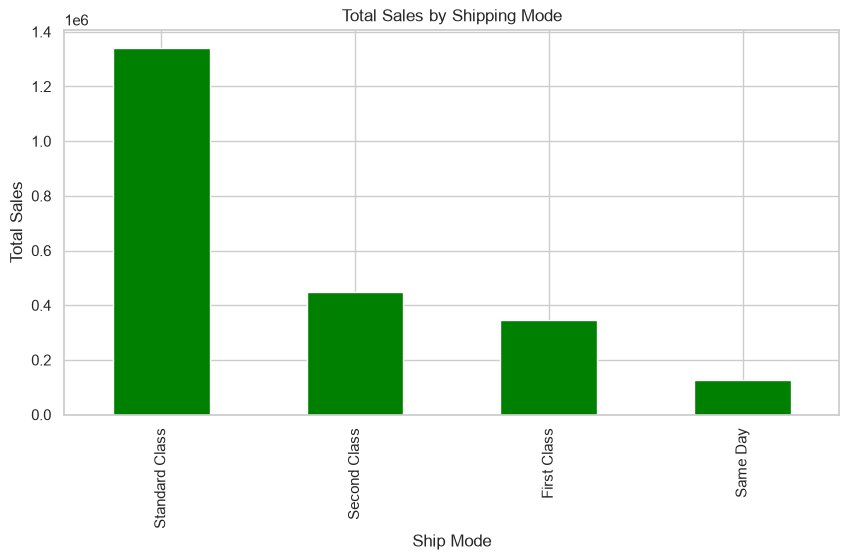

In [16]:
ship_sales = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)
ship_sales.plot(kind='bar', color='green', title='Total Sales by Shipping Mode')
plt.ylabel('Total Sales')
plt.show()

**Observation:** *(what non-obvious pattern did this reveal?)*


## Conclusion — Actionable Business Recommendations

1. (Recommendation 1): Double down on Technology, but investigate Office Supplies' underperformance. Technology drives the highest revenue while Office Supplies lags behind. The business should analyze whether Office Supplies is underpriced, under-marketed, or simply lower-value per unit — and consider bundling Office Supplies with high-performing Technology orders to lift their sales.

2. (Recommendation 2):Reduce dependency on Standard Class shipping by promoting faster options strategically. Standard Class dominates order volume, while Same Day shipping is barely used. Since Same Day is the fastest and often the most profitable option, the business could offer a targeted delivery-speed incentive (e.g. reduced fees) to shift a segment of Standard Class customers toward faster tiers, improving customer satisfaction and delivery revenue.

3. (Recommendation 3):Address the sales concentration risk. Sales are heavily skewed — the median sale (~$54) is far lower than the average (~$230), meaning revenue depends on a small number of large orders. The business should diversify its customer base or introduce mid-tier product bundles to reduce reliance on a handful of big transactions.
Paste these into your Conclusion — Actionable Business Recommendations section of the notebook, replacing the placeholder text. Once that's done and all your Observation lines are filled in, you're ready to save the notebook and push everything to GitHub. Want to go through that push process now?



